# pyinfercnv — Phase 2 quickstart (HMM subclusters + state calls)

End-to-end Phase 2 on the bundled oligodendroglioma downsampled fixture
(184 cells × 6,577 genes). The notebook:

1. Loads counts + cell-type annotations from the R package's `inst/extdata/`.
2. Builds an `AnnData` (cells × genes), attaches hg38 gene coordinates.
3. Runs `pyinfercnv.infercnv(...)` with `HMM=True, HMM_type="i6"` — tumor
   subclustering (step 15) + i6 state calls (step 17).
4. Runs the same pipeline again with `HMM_type="i3"` and shows how
   `result.hmm_states_i3` relates to `result.hmm_states`.
5. Tabulates per-block wall-clock (psutil profile).
6. Plots a heatmap of the log2(FC) matrix with sub-cluster row grouping.

The parity numbers that appear in this notebook come from
`tests/test_r_parity.py` and are regenerated every time R +
`tests/r_reference.R` produces the TSV fixtures under `tests/r_out/`.

**Scope this notebook does *not* cover**: the BayesNet posterior filter
(`result.posterior_p_normal`, Phase 3) and the denoise pass
(`infercnv::run(..., denoise=TRUE)`, documented in the R
[wiki](https://github.com/broadinstitute/inferCNV/wiki/De-noising-Filters)).
Keep `denoise=False` / `BayesMaxPNormal=0` for R-parity comparisons.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import dataclasses
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import anndata as ad

import pyinfercnv
from pyinfercnv import InferCNVConfig, infercnv
from pyinfercnv.io.genome import load_gene_positions
from pyinfercnv.viz import plot_cnv_heatmap

print("pyinfercnv version:", pyinfercnv.__version__)

pyinfercnv version: 0.2.0.dev0


## 1. Load the R fixture

Identical setup to `tutorial_phase1.py`. The fixture ships inside the R
`infercnv` package's `inst/extdata/` folder.


In [2]:
FIXTURE_DIR = Path(
    "/media/jason/T7/rerbulid/infercnv/infercnv-master/inst/extdata"
)
COUNTS_PATH = FIXTURE_DIR / "oligodendroglioma_expression_downsampled.counts.matrix.gz"
ANNOT_PATH = FIXTURE_DIR / "oligodendroglioma_annotations_downsampled.txt"

counts_gxc = pd.read_csv(COUNTS_PATH, sep="\t", index_col=0)
annot = pd.read_csv(
    ANNOT_PATH, sep="\t", header=None, names=["cell_id", "annotation"]
).set_index("cell_id")

cells = list(counts_gxc.columns)
X = counts_gxc.T.values.astype(np.float32)
adata = ad.AnnData(
    X=X, obs=annot.reindex(cells),
    var=pd.DataFrame(index=counts_gxc.index),
)
adata.obs.index.name = None
adata.var.index.name = None
adata.layers["counts"] = adata.X.copy()

gene_pos = load_gene_positions("hg38").drop_duplicates(
    subset="gene_symbol", keep="first"
)
var = adata.var.join(
    gene_pos.set_index("gene_symbol")[["chromosome", "start", "end"]],
    how="left",
)
for col in ("chromosome", "start", "end"):
    adata.var[col] = var[col].values

print(adata)
print("annotation counts:\n", adata.obs["annotation"].value_counts())

AnnData object with n_obs × n_vars = 184 × 10338
    obs: 'annotation'
    var: 'chromosome', 'start', 'end'
    layers: 'counts'
annotation counts:
 annotation
malignant_93                        40
malignant_97                        35
malignant_MGH53                     34
malignant_MGH36                     33
Oligodendrocytes (non-malignant)    23
Microglia/Macrophage                19
Name: count, dtype: int64


## 2. Phase 2 configuration

The R `infercnv::run(...)` call that produces the tier-3.5 reference is
in `tests/r_reference.R` (lines 149-166). Four settings matter for parity:

| R kwarg | value | why |
|---|---|---|
| `HMM` | `TRUE` | enables steps 15 → 17 (subcluster + HMM) |
| `HMM_type` | `"i6"` or `"i3"` | 6-state vs 3-state Viterbi. **One call produces one**. |
| `leiden_method` | `"simple"` | R default is `"PCA"` (Seurat SNN + irlba), which has no Python analogue. `"simple"` is euclidean KNN + `igraph::cluster_leiden`, whose C core matches Python's `python-igraph.community_leiden`. |
| `leiden_function` | `"CPM"` | Constant-Potts objective, shared with Python. `"modularity"` would diverge. |

`pyinfercnv.InferCNVConfig` pins equivalents for all four. `cutoff=1` is
the smart-seq2 value from the R wiki — switch to `0.1` for 10x Genomics
data (see the 3CA benchmark under `scripts/phase2_benchmark/`).


In [3]:
REFERENCE_CATS = ["Microglia/Macrophage", "Oligodendrocytes (non-malignant)"]

cfg_i6 = InferCNVConfig(
    cutoff=1.0,
    HMM=True,
    HMM_type="i6",
    BayesMaxPNormal=0.0,          # Phase 3 filter off — R parity calls for 0.
    cluster_by_groups=True,
    tumor_subcluster_partition_method="leiden",
    num_threads=1,                 # match r_reference.R for reproducibility
    prune_outliers=True,
)
cfg_i6.validate()
print("cfg_i6:", cfg_i6)

cfg_i6: InferCNVConfig(cutoff=1.0, min_cells_per_gene=3, window_length=101, smooth_method='pyramidinal', num_ref_groups=None, ref_subtract_use_mean_bounds=True, max_centered_threshold=3.0, scale_data=False, prune_outliers=True, outlier_method_bound='average_bound', outlier_lower_bound=None, outlier_upper_bound=None, counts_layer='counts', chr_exclude=('chrX', 'chrY', 'chrM'), HMM=True, HMM_type='i6', HMM_transition_prob=1e-06, HMM_i3_pval=0.05, BayesMaxPNormal=0.0, analysis_mode='subclusters', tumor_subcluster_partition_method='leiden', cluster_by_groups=True, lfc_clip=3.0, denoise=False, noise_filter=None, sd_amplifier=1.5, debug=False, num_threads=1)


## 3. Run — `HMM_type="i6"`


In [4]:
result_i6 = infercnv(
    adata,
    config=cfg_i6,
    reference_key="annotation",
    reference_cat=REFERENCE_CATS,
    inplace=False,
)
assert result_i6 is not None
print(f"n_cells     = {result_i6.cnv_matrix.shape[0]}")
print(f"n_bins      = {result_i6.cnv_matrix.shape[1]}")
print(f"subclusters = {np.unique(result_i6.subclusters).size} unique labels")
print(f"hmm_states  shape = {result_i6.hmm_states.shape}, dtype = {result_i6.hmm_states.dtype}")
print(f"state codes (py, 0-indexed) = {sorted(np.unique(result_i6.hmm_states))}")
print(f"cnv_regions rows = {0 if result_i6.cnv_regions is None else len(result_i6.cnv_regions)}")

n_cells     = 184
n_bins      = 7931
subclusters = 6 unique labels
hmm_states  shape = (184, 7931), dtype = int8
state codes (py, 0-indexed) = [np.int8(1), np.int8(2), np.int8(3), np.int8(4)]
cnv_regions rows = 80


**State encoding gotcha.** pyinfercnv stores HMM states 0-indexed (i6: 0-5,
neutral=2; i3: 0-2, neutral=1). R infercnv's `@expr.data` is 1-indexed
(i6: 1-6, neutral=3; i3: 1-3, neutral=2). Subtract 1 from the R TSV before
elementwise comparison — `tests/test_r_parity.py` does this at line 516.


## 4. Run — `HMM_type="i3"`

A second full pipeline run. Phase 1 work could be reused if we refactored,
but keeping two independent runs matches the R `tests/r_reference.R` flow
that dumps `step17_hmm_i3.tsv` and `step17_hmm_i6.tsv` separately.


In [5]:
cfg_i3 = dataclasses.replace(cfg_i6, HMM_type="i3")
result_i3 = infercnv(
    adata,
    config=cfg_i3,
    reference_key="annotation",
    reference_cat=REFERENCE_CATS,
    inplace=False,
)
assert result_i3 is not None and result_i3.hmm_states_i3 is not None
print(f"hmm_states_i3 shape = {result_i3.hmm_states_i3.shape}")
print(f"state codes (py, 0-indexed) = {sorted(np.unique(result_i3.hmm_states_i3))}")

hmm_states_i3 shape = (184, 7931)
state codes (py, 0-indexed) = [np.int8(0), np.int8(1), np.int8(2)]


## 5. Per-block wall-clock / RSS (psutil profile)


In [6]:
def _format_profile(result, label):
    rows = []
    for name, entry in (result.profile or {}).items():
        rows.append({
            "block": name,
            "wallclock_s": round(entry["wallclock_s"], 4),
            "rss_delta_mb": (
                round(entry["rss_delta_mb"], 1)
                if entry.get("rss_delta_mb") is not None else None
            ),
        })
    df = pd.DataFrame(rows)
    print(f"\n=== {label} ===")
    print(df.to_string(index=False))
    print(f"total wallclock: {df['wallclock_s'].sum():.3f} s")
    return df

_format_profile(result_i6, "HMM_type=i6")
_format_profile(result_i3, "HMM_type=i3")


=== HMM_type=i6 ===
               block  wallclock_s  rss_delta_mb
          01_extract       0.0320           5.0
  02_capture_ref_raw       0.0008           0.2
     03_filter_genes       0.0079           6.0
        04_normalize       0.0046           0.3
             05_log2       0.0144          10.9
          06_densify       0.0014           0.0
   07_subtract_ref_1       0.0252           3.3
    08_max_threshold       0.0007           0.0
           09_smooth       0.3783          35.3
           10_center       0.0091           5.7
   11_subtract_ref_2       0.0084           5.6
      12_invert_log2       0.0036           0.0
    13_outlier_prune       0.0056           5.6
       15_subcluster       1.9073          19.2
          hspike_sim       0.1118          30.6
hspike_phase1_replay       0.2021          28.9
    hspike_get_dists       0.0119           0.0
     hspike_trend_lm       0.0492           0.2
 16_hspike_calibrate       0.3874          -1.5
              17_hm

,block,wallclock_s,rss_delta_mb
0,01_extract,0.0229,2.9
1,02_capture_ref_raw,0.0006,0.0
2,03_filter_genes,0.0054,0.0
3,04_normalize,0.0034,0.0
4,05_log2,0.0121,2.7
5,06_densify,0.0018,0.0
6,07_subtract_ref_1,0.0258,2.7
7,08_max_threshold,0.0007,0.0
8,09_smooth,0.0129,0.4
9,10_center,0.0077,2.8


Where the time goes (`pyinfercnv.pipeline_phase2`):

* `15_subcluster` — `pyinfercnv.subcluster.leiden.subcluster_leiden`
  (python-igraph C-core Leiden, runs per annotation group under
  `cluster_by_groups=True`).
* `16_hspike_calibrate` — i6 only. Builds the h-spike synthetic CNV
  matrix, fits a log-space SD trend via `scipy.stats.linregress`. i3 skips
  this block.
* `17_hmm` — the `@njit` Viterbi kernel
  (`pyinfercnv.kernels.hmm_viterbi_numba`). First call pays a small JIT
  compile cost; subsequent calls are cache-hits.
* `18_cnv_regions` — per-cell RLE over the state matrix to build a BED-
  like region table (`pd.DataFrame` with `[cell_group, chromosome, start,
  end, state]`).


## 6. Heatmap with subcluster grouping

Phase 1's `plot_cnv_heatmap` takes the log2(FC) matrix and a chromosome
strip. For Phase 2 we show two panels side-by-side: tumor cells grouped by
subcluster label (top), and the HMM i6 state matrix (bottom) in the same
row order so segment boundaries line up visually.


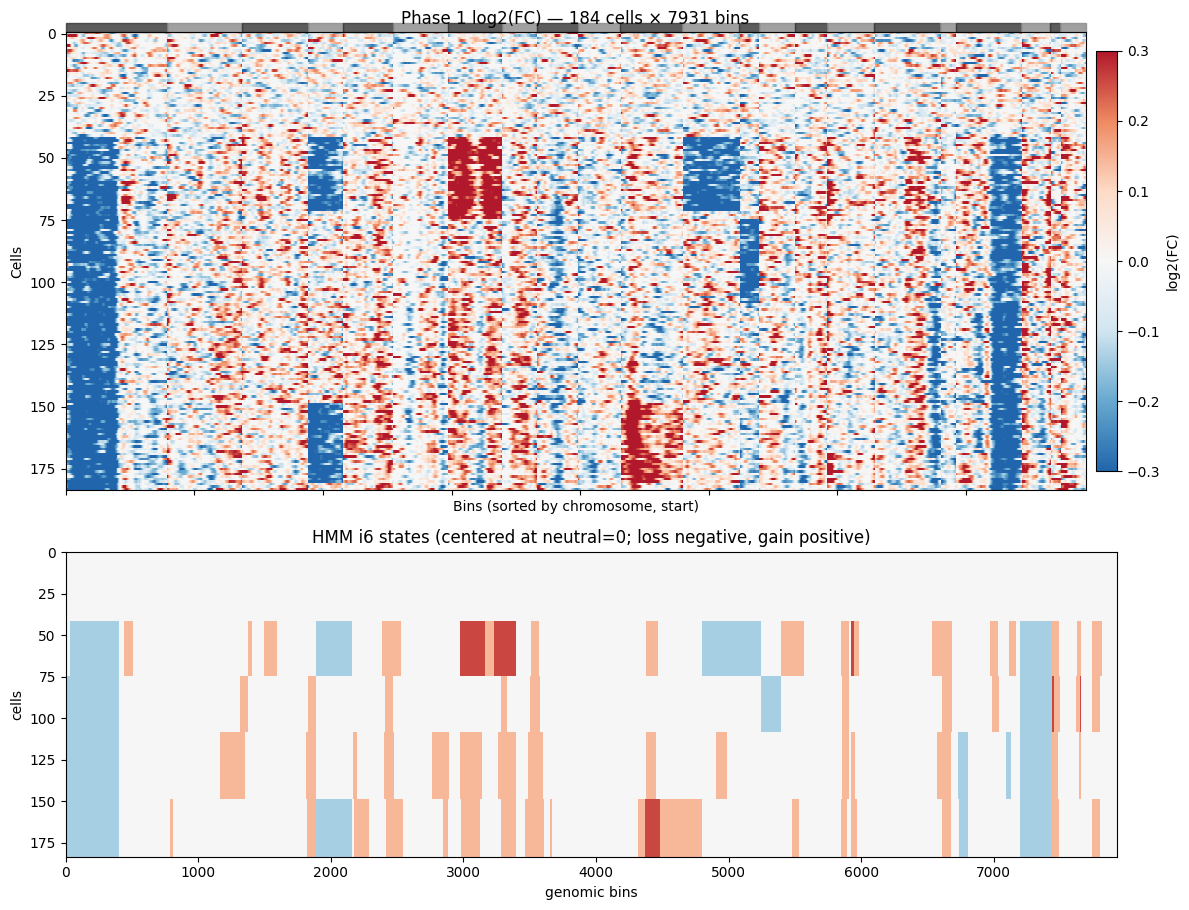

In [7]:
fig, axes = plt.subplots(
    2, 1, figsize=(12, max(8, result_i6.cnv_matrix.shape[0] / 20)),
    gridspec_kw={"height_ratios": [3, 2]}, sharex=True,
)
plot_cnv_heatmap(result_i6, ax=axes[0], vmin=-0.3, vmax=0.3)
axes[0].set_title(
    f"Phase 1 log2(FC) — {result_i6.cnv_matrix.shape[0]} cells × "
    f"{result_i6.cnv_matrix.shape[1]} bins"
)

# HMM state matrix: i6 states in {0,1,2,3,4,5}; neutral=2 in py coding.
# Recolor as signed deviation from neutral for readability.
hmm = np.asarray(result_i6.hmm_states, dtype=np.int8) - 2
axes[1].imshow(hmm, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3, interpolation="nearest")
axes[1].set_title("HMM i6 states (centered at neutral=0; loss negative, gain positive)")
axes[1].set_ylabel("cells")
axes[1].set_xlabel("genomic bins")
plt.tight_layout()
plt.show()

## 7. Parity with R `infercnv::run(..., HMM=TRUE)`

Empirical tier-3.5 numbers from `tests/test_r_parity.py` (oligodendroglioma
fixture, `leiden_method="simple"`, `leiden_function="CPM"`):

| metric | py vs R | test floor | spec §5.2 target |
|---|---|---|---|
| step 15 subcluster ARI | **1.000** | 0.85 | 0.85 |
| step 17 HMM i3 Jaccard | **0.976** | 0.90 | ~0.95 |
| step 17 HMM i6 Jaccard | **0.968** | 0.90 | ~0.95 |

These numbers are strictly for the oligodendroglioma smart-seq2 fixture. The
3CA UMI benchmark (17 patients, `scripts/phase2_benchmark/`) is a
separate cross-cohort measurement. Run
`scripts/phase2_benchmark/run_all.py` + `aggregate.py` to regenerate.
On 10x UMI data, remember to pass `cutoff=0.1` (not 1.0) — that is the
only data-type-dependent parameter change.


## 8. `result.cnv_regions` — BED-like region calls

RLE over the HMM state matrix gives a per-cell-group, per-chromosome
segment table. Columns: `cell_group, chromosome, start, end, state`. When
`BayesMaxPNormal > 0` (Phase 3), a `posterior_p_normal` column is added.


In [8]:
if result_i6.cnv_regions is not None and len(result_i6.cnv_regions) > 0:
    print(result_i6.cnv_regions.head(10).to_string(index=False))
    print(f"\n... {len(result_i6.cnv_regions)} total regions")
else:
    print("No cnv_regions produced — check that HMM=True is set in config.")

  cell_group  subcluster chromosome  bin_start  bin_end  state  cn
subcluster_2           2       chr1         32      398      1 0.5
subcluster_2           2       chr1        438      507      3 1.5
subcluster_2           2       chr3       1370     1398      3 1.5
subcluster_2           2       chr3       1495     1589      3 1.5
subcluster_2           2       chr4       1883     2155      1 0.5
subcluster_2           2       chr5       2385     2528      3 1.5
subcluster_2           2       chr7       2969     3160      4 2.0
subcluster_2           2       chr7       3161     3228      3 1.5
subcluster_2           2       chr7       3229     3392      4 2.0
subcluster_2           2       chr8       3509     3568      3 1.5

... 80 total regions


## Next steps / pointers

* **R side** — run `examples/r_driver_phase2.R` (sibling to this tutorial)
  to regenerate the R reference outputs on the same fixture.
* **Phase 3 (denoise + BayesNet)** — not covered here. Set `denoise=True`
  and `BayesMaxPNormal > 0` once the Python side lands this stage.
* **3CA cross-cohort benchmark** — `scripts/phase2_benchmark/` iterates
  pycopykat's 17-patient manifest. Outputs land under
  `benchmarks/phase2/` and feed the README "Cross-cohort parity" table.
* **Bug reports / parity regressions** — before filing, please include
  the `result.profile` dict and the version strings from
  `Rscript -e 'packageVersion("infercnv")'` and
  `python -c "import pyinfercnv; print(pyinfercnv.__version__)"`.
